# Quantum Reservoir Computing — Swaption Price Forecasting

## Strategy

**Hybrid Model:** A fixed quantum photonic circuit (the *reservoir*) is the nonlinear feature
engine; a classical Ridge regression (the *readout*) is the only trained component.

**Why QRC?**
- **No barren plateaus.** The quantum circuit is random and fixed — we never train it.
  Training is confined to a Ridge regression, which is convex and instant.
- **Small-data friendly.** Our LSTM needed 218K params for 435 samples.
  QRC has *zero* trainable quantum parameters — only the readout weights.
- **NISQ-native.** The natural "scrambled" dynamics of photonic hardware *are*
  the feature map. Noise helps rather than hurts.

## Why Quantum Encoding Matters

Financial instruments (swaptions) form a *correlated surface* — the 2Y rate and 10Y rate
co-move. Quantum encoding exploits this:
- **Entanglement ≈ Correlation.** Entangling layers link modes, mirroring how tenors
  and maturities co-move in rate markets.
- **Kernel Trick.** Angle encoding + multi-photon interference maps the price surface
  into an exponentially large Hilbert space where prediction becomes (near-)linear.
- **Memory via Hidden Modes.** We divide modes into *input* (data) and *hidden* (memory).
  Sequential encoding of multiple days lets past data persist in hidden modes through
  entangling layers — the circuit "remembers" prior market conditions.

## Architecture

```
Day t-2 ──→  [Entangle] → [Encode on input modes] ──→
Day t-1 ──→  [Entangle] → [Encode on input modes] ──→  ← info from t-2 persists in hidden modes
Day t   ──→  [Entangle] → [Encode on input modes] ──→
              [Entangle] → [Measure probabilities]  → 252 features
```

Slide this across a 20-day window → stack features → RidgeCV → forecast 10 days × 224 prices.

**Hardware constraints:** ≤ 20 modes / 10 photons (sim) · angle encoding only (QPU-compatible).

In [6]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
import matplotlib.pyplot as plt
import perceval as pcvl
from merlin import (
    QuantumLayer,
    CircuitBuilder,
    LexGrouping,
    MeasurementStrategy,
    ComputationSpace,
)

# ---- Config (matches classical baselines) ----
WINDOW   = 20       # lookback window (trading days)
HORIZON  = 10       # forecast horizon
VAL_SIZE = 30       # held-out validation days

# ---- QRC Config ----
N_MODES   = 10      # total photonic modes (≤20 sim, ≤24 QPU)
N_PHOTONS = 5       # photon count          (≤10 sim, ≤12 QPU)
N_PCA     = 4       # PCA components per day → encoded on 4 "input" modes
N_STEPS   = 3       # temporal depth: encode N_STEPS consecutive days per circuit eval
INPUT_MODES  = list(range(N_PCA))           # modes 0-3: data encoding
HIDDEN_MODES = list(range(N_PCA, N_MODES))  # modes 4-9: memory

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Input modes:  {INPUT_MODES}  (data encoding)")
print(f"Hidden modes: {HIDDEN_MODES}  (memory)")
print(f"Temporal depth: {N_STEPS} days per quantum evaluation")

Input modes:  [0, 1, 2, 3]  (data encoding)
Hidden modes: [4, 5, 6, 7, 8, 9]  (memory)
Temporal depth: 3 days per quantum evaluation


## 1 · Data Preparation

Load the swaption price surface (494 days × 224 instruments), standardise on the
training split, then compress with PCA to **4 components per day** that fit the
4 input modes of the reservoir. Scale PCA outputs to [0, π] for angle encoding.

In [7]:
# --- Load ---
df = pd.read_parquet("../data/level1.parquet")
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)
price_cols = [c for c in df.columns if c != 'Date']
prices = df[price_cols].astype(float).values  # (494, 224)

# --- StandardScaler (fit on train only) ---
scaler = StandardScaler()
scaler.fit(prices[:-VAL_SIZE])
prices_scaled = scaler.transform(prices)

# --- PCA: 224 → N_PCA ---
pca = PCA(n_components=N_PCA, random_state=SEED)
pca.fit(prices_scaled[:-VAL_SIZE])
prices_pca = pca.transform(prices_scaled)  # (494, 4)

# --- Angle encoding: scale to [0, π] ---
pca_min = prices_pca[:-VAL_SIZE].min(axis=0)
pca_max = prices_pca[:-VAL_SIZE].max(axis=0)
prices_angles = (prices_pca - pca_min) / (pca_max - pca_min + 1e-8) * np.pi

var_expl = pca.explained_variance_ratio_.sum()
print(f"Raw data:  {prices.shape}")
print(f"PCA:       {prices_pca.shape}  (variance explained: {var_expl:.3f})")
print(f"Angles:    [{prices_angles.min():.3f}, {prices_angles.max():.3f}] rad")

Raw data:  (494, 224)
PCA:       (494, 4)  (variance explained: 1.000)
Angles:    [-0.047, 3.142] rad


## 2 · Quantum Encoding Architecture — The Core of QRC

This is the heart of the model. The circuit implements the **memory loop**:

| Step | Circuit Operation | Purpose |
|------|------------------|---------|
| 1 | `add_entangling_layer` (fixed) | Initial mixing — creates baseline interference |
| 2 | `add_angle_encoding` on input modes [0–3] | Encode **day t−2** as phase shifts |
| 3 | `add_entangling_layer` (fixed) | **Scramble** — spreads day t−2 info into hidden modes [4–9] |
| 4 | `add_angle_encoding` on input modes [0–3] | Encode **day t−1** (overwrites input modes) |
| 5 | `add_entangling_layer` (fixed) | Scramble — t−1 mixes with t−2 residue in hidden modes |
| 6 | `add_angle_encoding` on input modes [0–3] | Encode **day t** |
| 7 | `add_entangling_layer` (fixed) | Final scramble before measurement |

**Why this works:**
- After step 3, hidden modes carry a nonlinear imprint of day t−2.
- After step 5, hidden modes carry a *mixture* of t−2 and t−1 — this is the **memory**.
- The final measurement captures correlations across *all three days* in a single
  probability distribution over Fock states.

**Zero trainable quantum parameters.** Every entangling layer is `trainable=False`.
The circuit is a fixed nonlinear kernel — only the downstream Ridge is trained.

Circuit: 10 modes, 5 photons, 3 encoding steps
Input:   3 × 4 = 12 angle parameters
Output:  10 mode expectations → 200 features/window
Fixed random params: 360  |  Trainable: 0



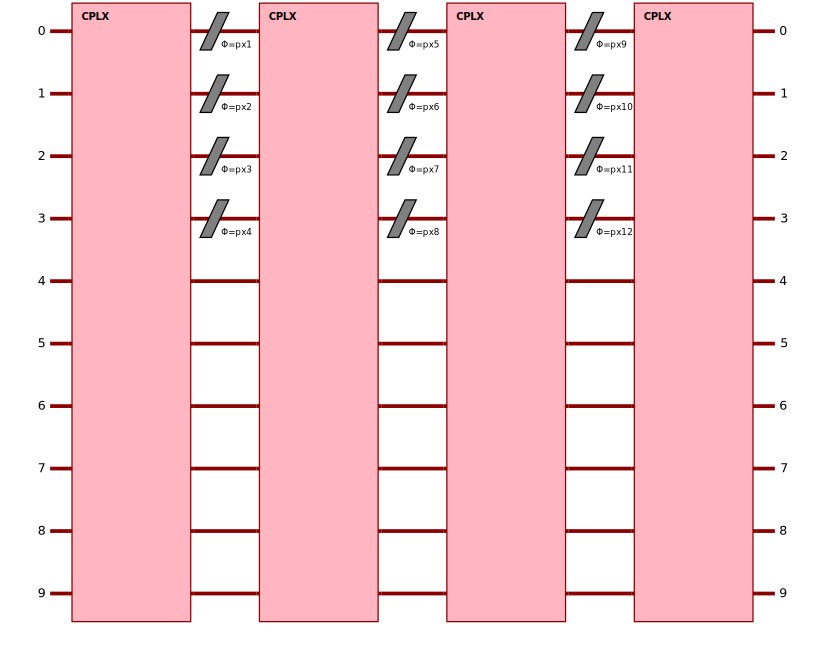

In [8]:
# --- Build the memory-loop reservoir circuit ---
# trainable=True so params are registered; we randomize then freeze below.
# With trainable=False params default to 0 → identity → no mixing → dead features.
builder = CircuitBuilder(n_modes=N_MODES)

for step in range(N_STEPS):
    builder.add_entangling_layer(trainable=True)     # will randomize & freeze
    builder.add_angle_encoding(modes=INPUT_MODES)    # encode one day on input modes

builder.add_entangling_layer(trainable=True)         # final mixing before measurement

reservoir = QuantumLayer(
    input_size=N_STEPS * N_PCA,    # 3 days × 4 PCA features = 12 inputs
    builder=builder,
    n_photons=N_PHOTONS,
    measurement_strategy=MeasurementStrategy.MODE_EXPECTATIONS,  # 10 features (not 252)
    computation_space=ComputationSpace.UNBUNCHED,
    dtype=torch.float64,
)

# RANDOMIZE then FREEZE — true reservoir (random but fixed)
torch.manual_seed(SEED)
with torch.no_grad():
    for p in reservoir.parameters():
        p.uniform_(0, 2 * np.pi)
        p.requires_grad = False

q_out_dim = reservoir.output_size
n_fixed = sum(p.numel() for p in reservoir.parameters())
n_trainable = sum(p.numel() for p in reservoir.parameters() if p.requires_grad)
print(f"Circuit: {N_MODES} modes, {N_PHOTONS} photons, {N_STEPS} encoding steps")
print(f"Input:   {N_STEPS} × {N_PCA} = {N_STEPS * N_PCA} angle parameters")
print(f"Output:  {q_out_dim} mode expectations → {WINDOW * q_out_dim} features/window")
print(f"Fixed random params: {n_fixed}  |  Trainable: {n_trainable}")
print()
pcvl.pdisplay(reservoir.circuit)

## 3 · Quantum Feature Extraction

Since the reservoir is **fixed**, every circuit evaluation is deterministic for a given input.
We pre-compute quantum features for all overlapping 3-day blocks once — no per-epoch re-simulation.

For each index *i*, we feed `[day_i, day_i+1, day_i+2]` → circuit → probability vector.
This produces **492 feature vectors** (494 − 3 + 1). We then window these exactly like the
classical baselines.

In [9]:
%%time
# --- Build N_STEPS-day blocks and encode through reservoir ---
n_blocks = len(prices_angles) - N_STEPS + 1  # 494 - 3 + 1 = 492
q_features = np.empty((n_blocks, q_out_dim))

with torch.no_grad():
    for i in range(n_blocks):
        # Concatenate N_STEPS consecutive days: shape (N_STEPS * N_PCA,) = (12,)
        block = prices_angles[i:i + N_STEPS].flatten()
        x = torch.tensor(block[np.newaxis, :], dtype=torch.float64)
        q_features[i] = reservoir(x).numpy().flatten()
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{n_blocks} blocks")

nz = (q_features[0] > 1e-10).sum()
print(f"\nQuantum features: {q_features.shape}")
print(f"Non-zero per block: {nz} / {q_out_dim}")
print(f"Range: [{q_features.min():.6f}, {q_features.max():.6f}]")

  100/492 blocks
  200/492 blocks
  300/492 blocks
  400/492 blocks

Quantum features: (492, 10)
Non-zero per block: 10 / 10
Range: [0.175185, 0.696212]
CPU times: total: 6.52 s
Wall time: 15.6 s


## 4 · Classical Readout & Results

**Ridge regression** maps windowed quantum features to price forecasts.
Same train/val split (last 30 days) and metrics (RMSE, MAE, QLIKE) as the classical baselines.
Test predictions are saved for the Test Evaluation notebook.

In [10]:
# ================================================================
# Helpers
# ================================================================
def build_windows(q_feats, targets_scaled, window, horizon, offset=0):
    X, Y = [], []
    for i in range(len(q_feats) - window - horizon + 1):
        X.append(q_feats[i:i + window].flatten())
        raw_target_start = i + offset + window
        Y.append(targets_scaled[raw_target_start:raw_target_start + horizon].flatten())
    return np.array(X), np.array(Y)

def compute_metrics(pred, actual):
    rmse = np.sqrt(((pred - actual) ** 2).mean())
    mae  = np.abs(pred - actual).mean()
    eps  = 1e-8
    ratio = actual / np.clip(pred, eps, None)
    qlike = (ratio - np.log(ratio) - 1).mean()
    return {'RMSE': rmse, 'MAE': mae, 'QLIKE': qlike}

# ================================================================
# Build windowed dataset
# ================================================================
X_all, Y_all = build_windows(q_features, prices_scaled, WINDOW, HORIZON, offset=N_STEPS - 1)

n_total   = len(prices_scaled)
val_start = n_total - VAL_SIZE
train_end = val_start - WINDOW - N_STEPS + 1 - HORIZON + 1

X_train, Y_train = X_all[:train_end], Y_all[:train_end]
X_val,   Y_val   = X_all[train_end:], Y_all[train_end:]
print(f"Windows: {len(X_all)} total -> {len(X_train)} train, {len(X_val)} val")
print(f"Feature dim: {X_train.shape[1]}  Target dim: {Y_train.shape[1]}")

# ================================================================
# Train Ridge
# ================================================================
ridge = RidgeCV(alphas=np.logspace(-3, 6, 50), scoring='neg_mean_squared_error')
ridge.fit(X_train, Y_train)
train_r2 = ridge.score(X_train, Y_train)
val_r2   = ridge.score(X_val, Y_val)
print(f"Ridge alpha = {ridge.alpha_:.4f}  |  Train R2 = {train_r2:.4f}  |  Val R2 = {val_r2:.4f}")

# ================================================================
# Validation metrics
# ================================================================
Y_val_hat = ridge.predict(X_val)
val_pred_list, val_true_list = [], []
for i in range(len(Y_val_hat)):
    val_pred_list.append(scaler.inverse_transform(Y_val_hat[i].reshape(HORIZON, 224)))
    val_true_list.append(scaler.inverse_transform(Y_val[i].reshape(HORIZON, 224)))
qrc_val = compute_metrics(np.concatenate(val_pred_list), np.concatenate(val_true_list))

# ================================================================
# Test prediction
# ================================================================
test_input = q_features[-WINDOW:].flatten().reshape(1, -1)
test_pred  = scaler.inverse_transform(ridge.predict(test_input).reshape(HORIZON, 224))

test_df = pd.read_excel("../data/test.xlsx")
test_df['Date'] = pd.to_datetime(test_df['Date'], format='mixed')
test_actual = test_df[price_cols].astype(float).values
N_TEST = len(test_actual)
qrc_test_pred = test_pred[:N_TEST]
qrc_test = compute_metrics(qrc_test_pred, test_actual)

np.save("../models/qrc_test_pred.npy", qrc_test_pred)

# ================================================================
# Comparison
# ================================================================
baselines = {
    'MLP':  {'RMSE': 0.0162, 'MAE': 0.0120, 'QLIKE': 0.003752},
    'LSTM': {'RMSE': 0.0155, 'MAE': 0.0116, 'QLIKE': 0.003293},
}
hdr = f"{'Metric':<8} {'MLP (val)':>12} {'LSTM (val)':>12} {'QRC (val)':>12} {'QRC (test)':>12}"
sep = '=' * len(hdr)
print()
print(sep)
print(hdr)
print('-' * len(hdr))
for m in ['RMSE', 'MAE', 'QLIKE']:
    mv = baselines['MLP'][m]
    lv = baselines['LSTM'][m]
    print(f"{m:<8} {mv:>12.6f} {lv:>12.6f} {qrc_val[m]:>12.6f} {qrc_test[m]:>12.6f}")
print(sep)
print(f"\nSaved: ../models/qrc_test_pred.npy  {qrc_test_pred.shape}")

Windows: 463 total -> 433 train, 30 val
Feature dim: 200  Target dim: 2240
Ridge alpha = 3.0888  |  Train R2 = 0.3179  |  Val R2 = -0.3374

Metric      MLP (val)   LSTM (val)    QRC (val)   QRC (test)
------------------------------------------------------------
RMSE         0.016200     0.015500     0.019021     0.010582
MAE          0.012000     0.011600     0.014142     0.008368
QLIKE        0.003752     0.003293     0.004899     0.001364

Saved: ../models/qrc_test_pred.npy  (6, 224)
